### Training convergence with confidence intervals

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.plot_utils import plot_convergence_ci

from utils.analyse_results import GraphsTraining, Results, ConvergenceCI, plot_convergence_debug, plot_multi_ci, load_all_pickles

train_info = GraphsTraining()

## Pyomo results

### [2, 16, 2]

In [3]:
fp_p1 = "results/ho_comparison/pyomo_ho_2_16_2_10_part_1.pkl"
fp_p2 = "results/ho_comparison/pyomo_ho_2_16_2_10_part_2.pkl"
results_li_p1 = Results.load_results(fp_p1)
results_li_p2 = Results.load_results(fp_p2)
results_li_16 = results_li_p1 + results_li_p2
results_df_16 = Results.flatten_convergence_data(results_li_16, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

In [4]:
fp_p1 = "results/ho_comparison/pyomo_ho_2_32_2_10_part_1.pkl"
fp_p2 = "results/ho_comparison/pyomo_ho_2_32_2_10_part_2.pkl"
results_li_p1 = Results.load_results(fp_p1)
results_li_p2 = Results.load_results(fp_p2)
results_li_32 = results_li_p1 + results_li_p2
results_df_32 = Results.flatten_convergence_data(results_li_32, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

In [5]:
fp_p1 = "results/ho_comparison/pyomo_ho_2_64_2_10_part_1.pkl"
results_li_64 = Results.load_results(fp_p1)
results_df_64 = Results.flatten_convergence_data(results_li_64, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

----
# HO comparison

#### pyomo

In [6]:
fp_p1 = "results/ho_comparison/pyomo_ho_2_32_2_10_part_1.pkl"
fp_p2 = "results/ho_comparison/pyomo_ho_2_32_2_10_part_2.pkl"
results_li_p1 = Results.load_results(fp_p1)
results_li_p2 = Results.load_results(fp_p2)
results_li_32 = results_li_p1 + results_li_p2
pyomo_results_df_32 = Results.flatten_convergence_data(results_li_32, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

In [7]:
pyomo_comparison_dfs = {
    "pyomo_32": results_df_32,
    "pyomo_64": results_df_64,
    "pyomo_16": results_df_16,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:485: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


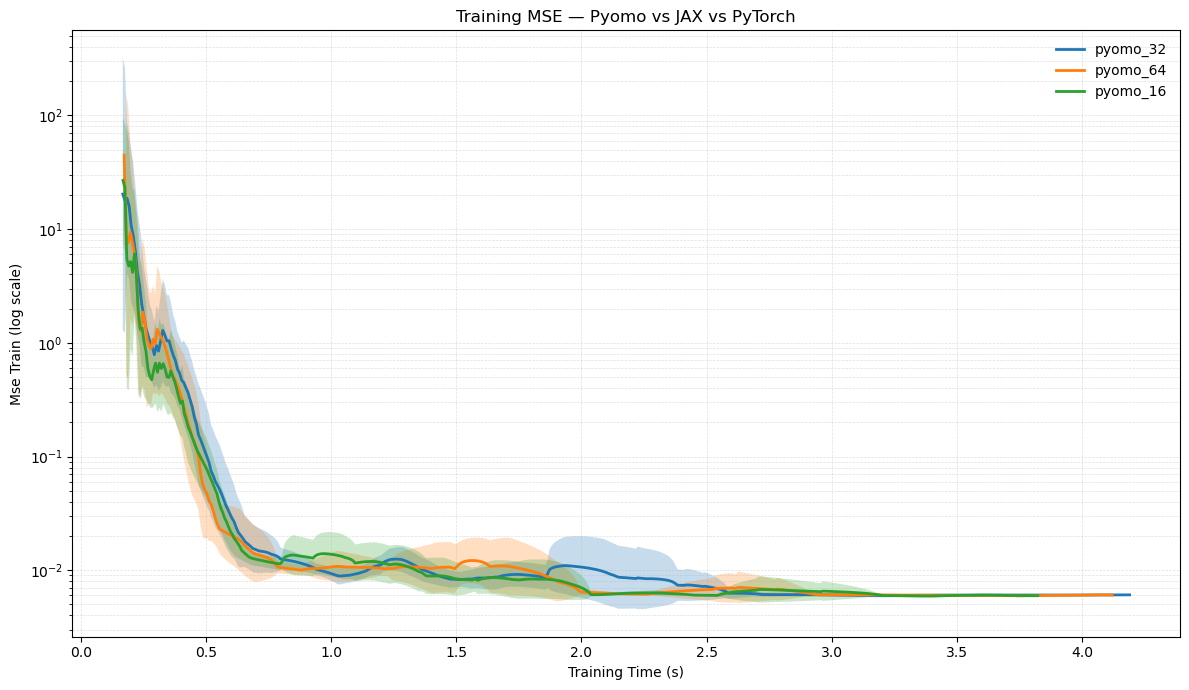

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [8]:
plot_multi_ci(
    pyomo_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

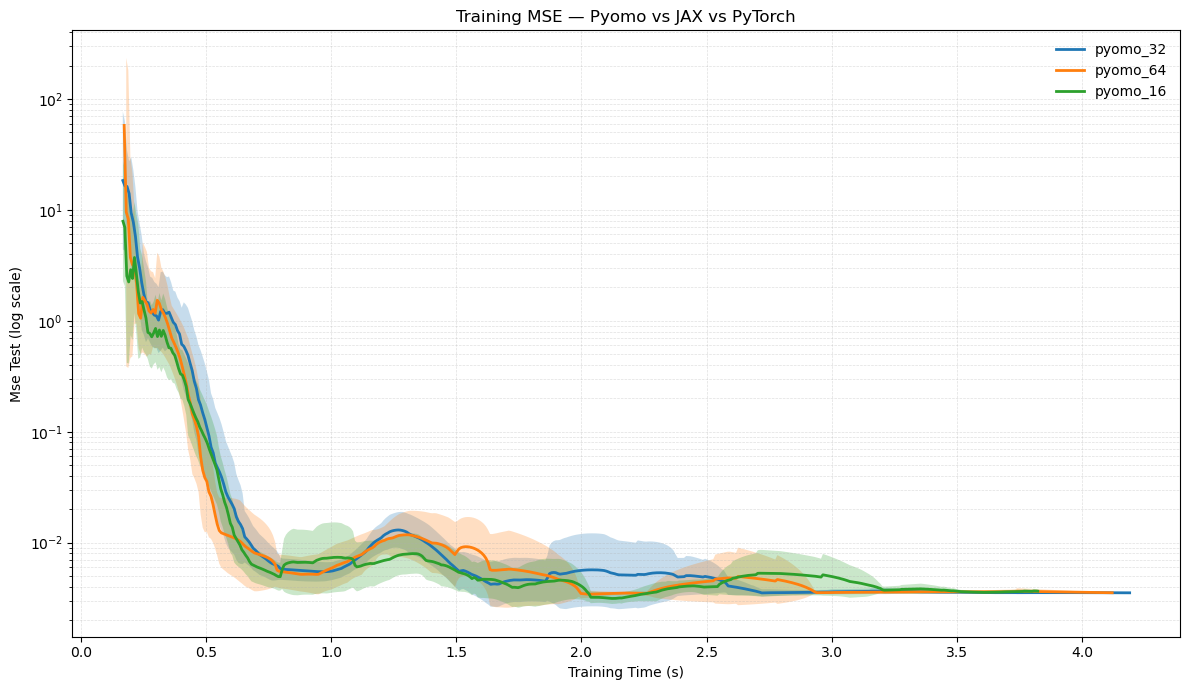

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [9]:
plot_multi_ci(
    pyomo_comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

#### pytorch

In [10]:
fp = "results/ho_comparison/pytoch_ho_400_pretrain_1000.pkl"
results = Results.load_results(fp)
pytoch_results_df_400 = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

fp = "results/ho_comparison/pytoch_ho_200_pretrain_1000.pkl"
results = Results.load_results(fp)
pytoch_results_df_200 = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

fp = "results/ho_comparison/pytoch_ho_no_pretrain_1000.pkl"
results = Results.load_results(fp)
pytoch_results_df_no_pretrain = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

In [11]:
pytorch_comparison_dfs = {
    "pytorch_no_pretrain": pytoch_results_df_no_pretrain,
    "pytorch_200": pytoch_results_df_200,
    "pytorch_400": pytoch_results_df_400,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:485: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


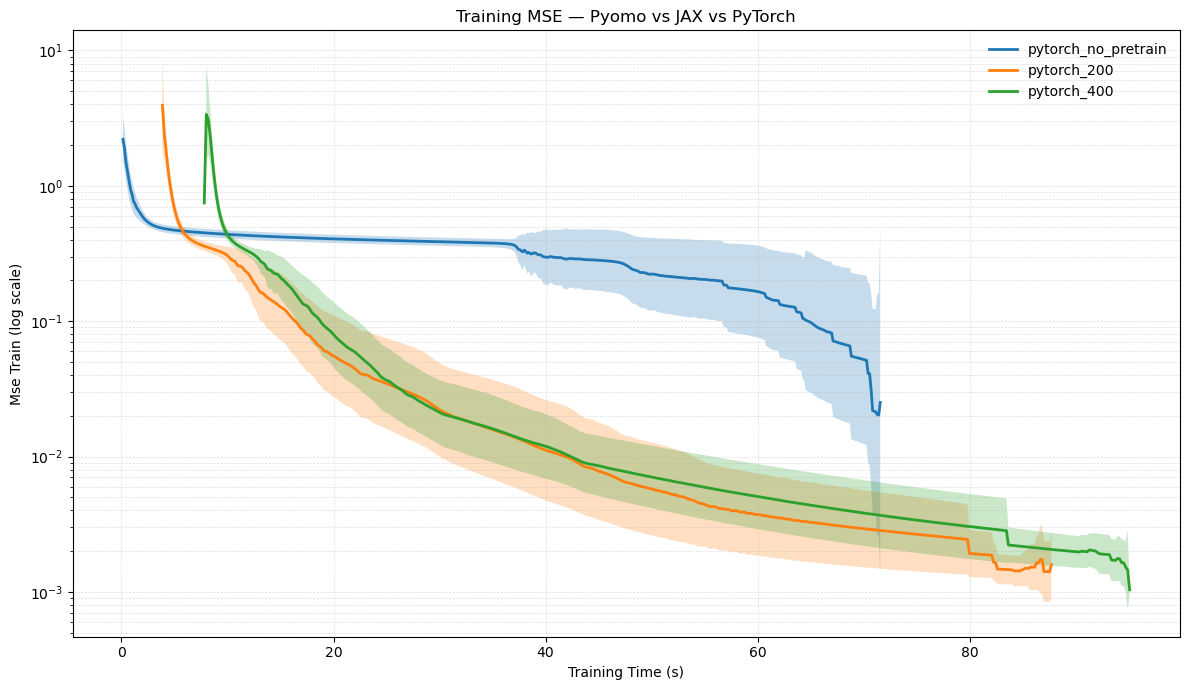

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [12]:
plot_multi_ci(
    pytorch_comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

### jax

In [13]:
results = load_all_pickles("results/ho_comparison/jax_ho_1000_5000", recursive=False)
jax_results_df_w_pretrain = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="jax")

results = load_all_pickles("results/ho_comparison/jax_ho_5000", recursive=False)
jax_results_df_no_pretrain = Results.flatten_convergence_data(results, key_list=["system", "pretrain", "max_t"], model_type="jax")

Loaded results/ho_comparison/jax_ho_1000_5000/1431430762_2025-11-02_15-46.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/1564400899_2025-11-02_15-54.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/1578204520_2025-11-02_15-58.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/1704643042_2025-11-02_15-38.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/1816736937_2025-11-02_15-42.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/1945287910_2025-11-02_15-50.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/2107939655_2025-11-02_15-36.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/2966145724_2025-11-02_15-56.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/311145238_2025-11-02_15-32.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/3408863211_2025-11-02_15-52.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/3601017084_2025-11-02_15-48.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/3737788536_2025-11-02_15-34.pkl
Loaded results/ho_comparison/jax_ho_1000_5000/3742291418_2025-11-

In [14]:
jax_comparison_dfs = {
    "JAX_no_pretrain": jax_results_df_no_pretrain,
    "JAX": jax_results_df_w_pretrain,
}

In [15]:
plot_multi_ci(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)

NameError: name 'comparison_dfs' is not defined

In [22]:
comparison_dfs = {
    "Pyomo": pyomo_results_df_32,
    "JAX": jax_results_df,
    "PyTorch": pytoch_results_df,
}

In [ ]:
plot_multi_ci(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = True
)

NameError: name 'plot_multi_ci' is not defined

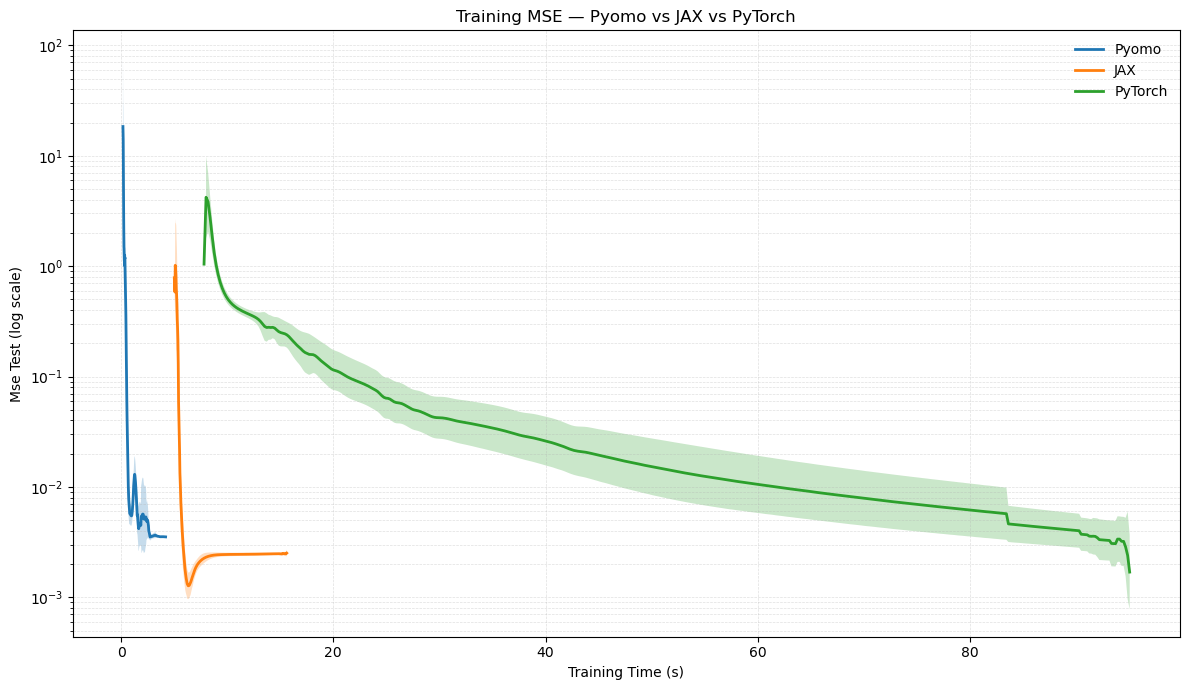

<Axes: title={'center': 'Training MSE — Pyomo vs JAX vs PyTorch'}, xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [24]:
plot_multi_ci(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="Training MSE — Pyomo vs JAX vs PyTorch",
    logy=True,
    align_grid = False
)